In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q git+https://github.com/roboflow/supervision.git
!pip install -q accelerate
!pip install -q roboflow
!pip install -q torchmetrics
!pip install -q "albumentations>=1.4.5"

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.5 MB/s eta 0:00:00


In [ ]:
import torch
import requests

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [ ]:
CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

The image processor of type `RTDetrImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [ ]:
!mkdir -p /content/drive/MyDrive/cfmodels
!unzip "/content/drive/MyDrive/QR-Code-1-20260319T125504Z-3-001.zip" -d /content/drive/MyDrive/cfmodels

In [ ]:
dataset_location = '/content/drive/MyDrive/cfmodels/QR-Code-1'


ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset_location}/train",
    annotations_path=f"{dataset_location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset_location}/valid",
    annotations_path=f"{dataset_location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset_location}/test",
    annotations_path=f"{dataset_location}/test/_annotations.coco.json",
)

print(f"Train images: {len(ds_train)}")
print(f"Valid images: {len(ds_valid)}")
print(f"Test images:  {len(ds_test)}")

# Mapping labels
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}

Train images: 2859
Valid images: 168
Test images:  168


In [ ]:
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

# We use NoOp (No Operation) to skip further augmentation
no_augmentation_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1
    ),
)

In [ ]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)
        return {"image_id": image_id, "annotations": annotations}

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # FIX: Added .copy() here to fix the negative stride error
        image = image[:, :, ::-1].copy()

        boxes = annotations.xyxy
        categories = annotations.class_id

        if self.transform:
            transformed = self.transform(image=image, bboxes=boxes, category=categories)
            image = transformed["image"]
            boxes = transformed["bboxes"]
            categories = transformed["category"]

        formatted_annotations = self.annotations_as_coco(idx, categories, boxes)

        # This is where the error was triggered; now it will work!
        result = self.processor(images=image, annotations=formatted_annotations, return_tensors="pt")
        return {k: v[0] for k, v in result.items()}

# Create instances (Using NoOp for all)
pytorch_dataset_train = PyTorchDetectionDataset(ds_train, processor, transform=no_augmentation_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(ds_valid, processor, transform=no_augmentation_transform)
pytorch_dataset_test = PyTorchDetectionDataset(ds_test, processor, transform=no_augmentation_transform)

In [ ]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor

class MAPEvaluator:
    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def __call__(self, evaluation_results):
        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        # Collect image sizes
        image_sizes = []
        for batch in targets:
            image_sizes.append(torch.tensor(np.array([x["size"] for x in batch])))

        # Post-process targets
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = sv.xcycwh_to_xyxy(target["boxes"])
                boxes = boxes * np.array([width, height, width, height])
                post_processed_targets.append({"boxes": torch.tensor(boxes), "labels": torch.tensor(target["class_labels"])})

        # Post-process predictions
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.update(post_processed_predictions, post_processed_targets)
        metrics = evaluator.compute()

        # Clean up output
        metrics.pop("classes"); metrics.pop("map_per_class"); metrics.pop("mar_100_per_class")
        return {k: round(v.item(), 4) for k, v in metrics.items()}

eval_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

In [ ]:
# 1. Load the model
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

# 2. Set Training Arguments

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/cfmodels/qr_code_model_results",
    num_train_epochs=20,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=16,
    dataloader_num_workers=2,
    metric_for_best_model="map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
)

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

RTDetrForObjectDetection LOAD REPORT from: PekingU/rtdetr_r50vd_coco_o365
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([2])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([2])          
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([2, 256])
model.enc_score_head.weight                         | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([2, 256])
model.de

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    # Removed 'tokenizer=processor' to fix the TypeError
    data_collator=collate_fn,
    compute_metrics=eval_metrics_fn,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large
1,No log,13.185242,0.685700,0.888900,0.737500,0.290900,0.507000,0.618900,0.707400,0.831100,0.848100,0.480000,0.766400,0.805400
2,No log,6.407501,0.783100,0.982200,0.882000,0.560000,0.682900,0.757900,0.746600,0.838500,0.866000,0.720000,0.795400,0.837600
3,74.392992,5.680543,0.795300,0.993600,0.875700,0.551500,0.701000,0.810800,0.761600,0.846100,0.861300,0.720000,0.787800,0.836400
4,74.392992,5.773427,0.794400,0.982400,0.861700,0.558900,0.700200,0.796900,0.760900,0.852800,0.869100,0.620000,0.796200,0.866100
5,74.392992,5.787688,0.784200,0.969200,0.870200,0.560600,0.687100,0.781700,0.754700,0.840500,0.857200,0.580000,0.782400,0.829300
6,8.955373,5.995622,0.768000,0.967000,0.849900,0.564900,0.664700,0.763000,0.751000,0.830900,0.831900,0.600000,0.742000,0.822300
7,8.955373,5.455373,0.790200,0.978400,0.869500,0.560600,0.698400,0.838500,0.760000,0.839200,0.841300,0.580000,0.769500,0.859300
8,8.955373,5.469653,0.793700,0.982300,0.869100,0.615800,0.704800,0.814700,0.766500,0.839700,0.840000,0.640000,0.764100,0.835500
9,7.583410,5.357091,0.792500,0.978600,0.870400,0.630000,0.703500,0.818200,0.770300,0.840900,0.841600,0.640000,0.764100,0.845000
10,7.583410,5.637843,0.785500,0.981300,0.863400,0.630000,0.689500,0.826300,0.762300,0.836300,0.836300,0.640000,0.752700,0.845000


Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['model.encoder.aifi.0.layers.0.self_attn.k_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.k_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.v_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.v_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.q_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.q_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn.o_proj.weight', 'model.encoder.aifi.0.layers.0.self_attn.o_proj.bias', 'model.encoder.aifi.0.layers.0.self_attn_layer_norm.weight', 'model.encoder.aifi.0.layers.0.self_attn_layer_norm.bias', 'model.encoder.aifi.0.layers.0.mlp.fc1.weight', 'model.encoder.aifi.0.layers.0.mlp.fc1.bias', 'model.encoder.aifi.0.layers.0.mlp.fc2.weight', 'model.encoder.aifi.0.layers.0.mlp.fc2.bias', 'model.encoder.aifi.0.layers.0.final_layer_norm.weight', 'model.encoder.aifi.0.layers.0.final_layer_norm.bias', 'model.decoder.layers.0.self_attn.o_proj.weight', 'model.decoder.layers.0.s

TrainOutput(global_step=3580, training_loss=16.015491992801262, metrics={'train_runtime': 6249.4105, 'train_samples_per_second': 9.15, 'train_steps_per_second': 0.573, 'total_flos': 1.0132934027065344e+19, 'train_loss': 16.015491992801262, 'epoch': 20.0})

In [ ]:
trainer.save_model("./final_qr_model")
processor.save_pretrained("./final_qr_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['./final_qr_model/preprocessor_config.json']

In [ ]:
targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [ ]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.84
map50: 0.99
map75: 0.91


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


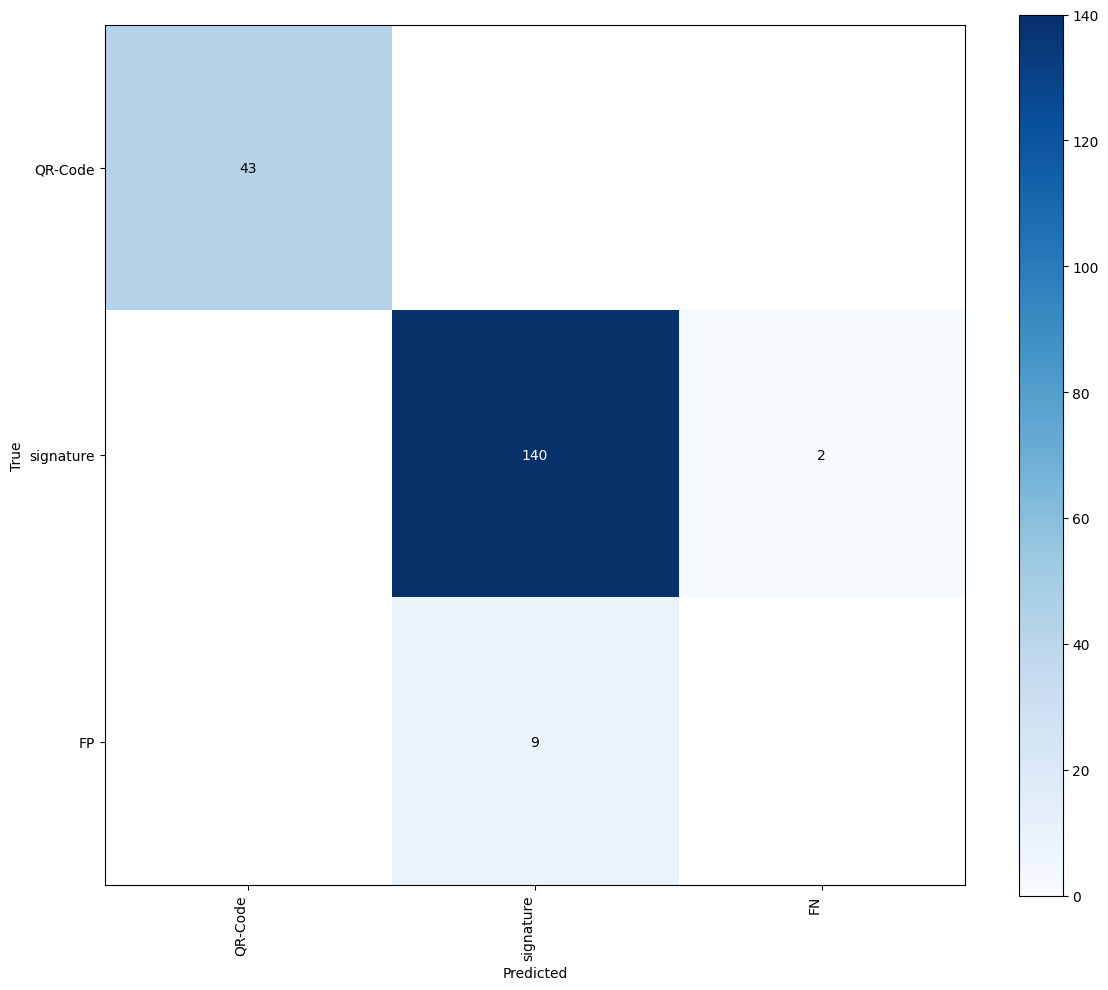

In [ ]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

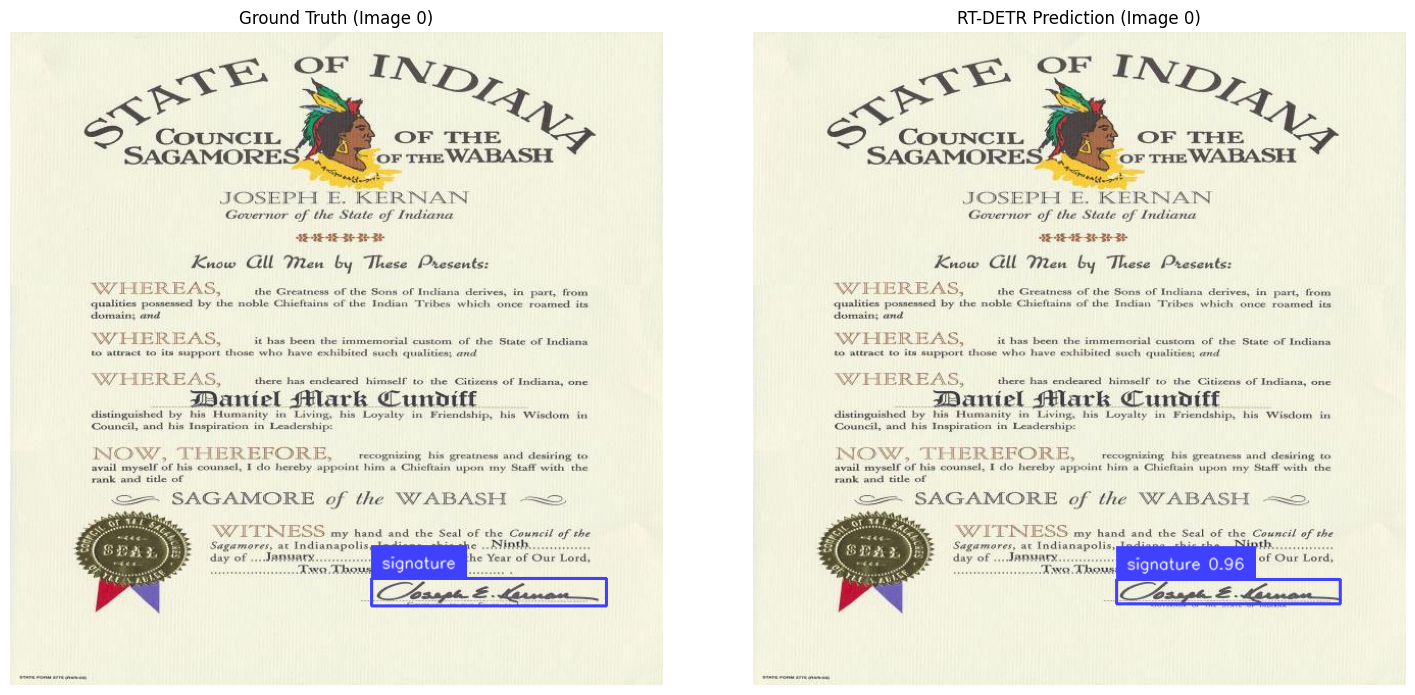

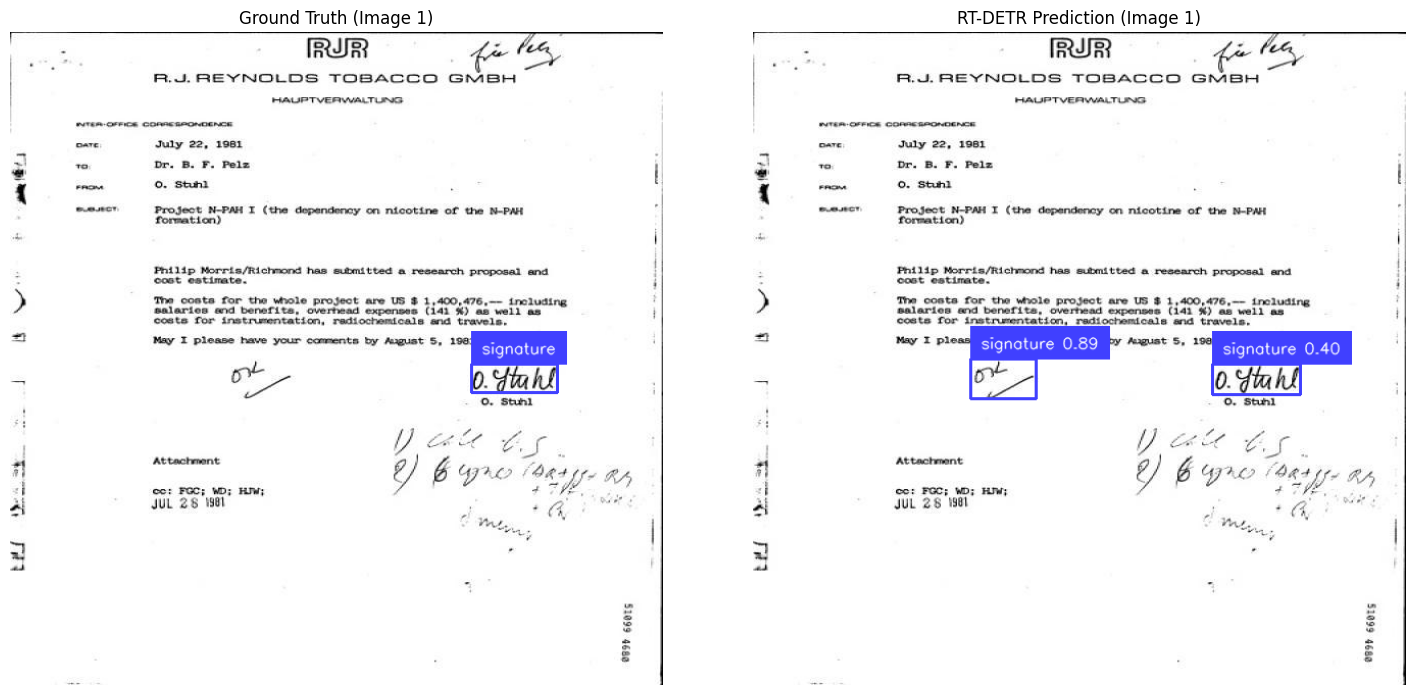

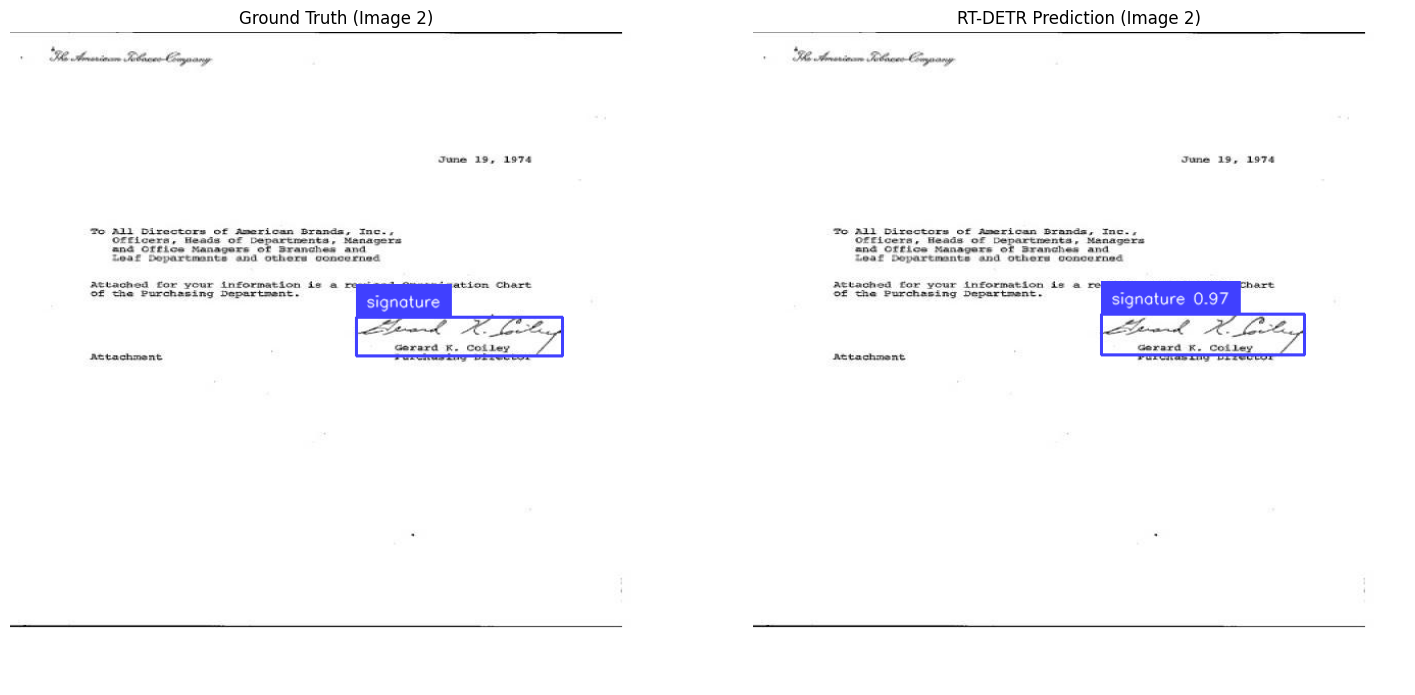

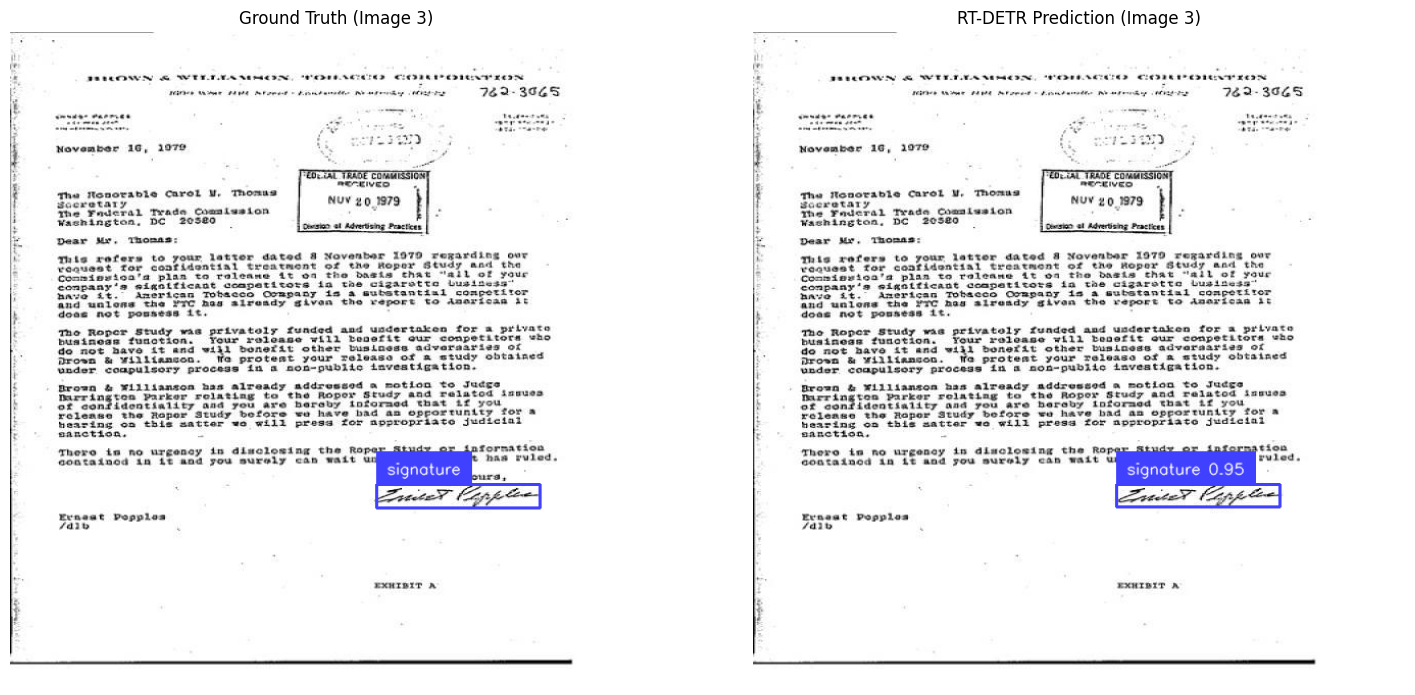

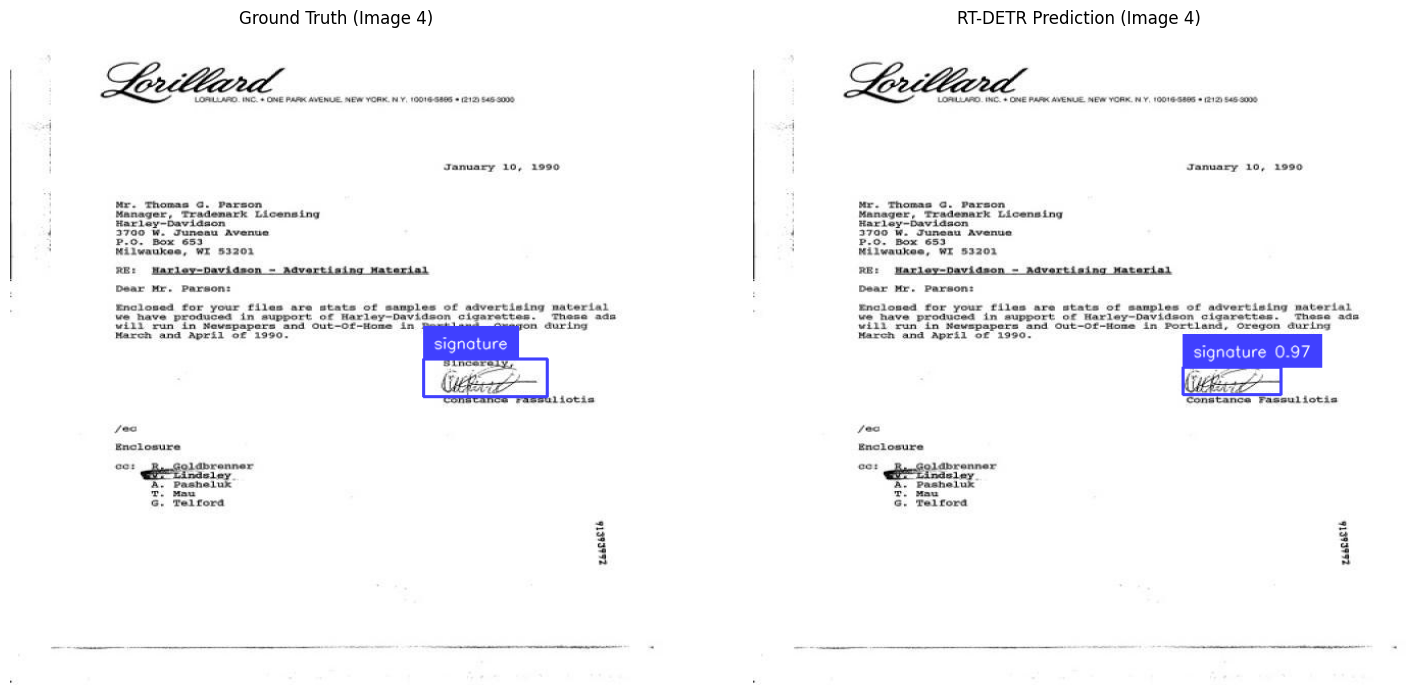

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import supervision as sv

# 1. Setup Annotators (Modern Supervision API)
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

def annotate_image(image, detections, labels):
    """Helper to draw boxes and labels on a numpy array."""
    # Ensure image is a copy so we don't overwrite the original
    annotated_frame = image.copy()
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
    return annotated_frame

# 2. Inference Loop
IMAGE_COUNT = 5
model.eval()

for i in range(IMAGE_COUNT):
    # Get data from dataset
    path, source_image, annotations = ds_test[i]

    # Supervision source_image is usually BGR, convert to RGB for Matplotlib/Processor
    image_rgb_np = source_image[:, :, ::-1].copy()
    image_pil = Image.fromarray(image_rgb_np)

    # Model Inference
    inputs = processor(image_pil, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)

    # Post-processing
    w, h = image_pil.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3
    )

    # Convert to supervision detections and apply NMS
    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    # Prepare Labels
    gt_labels = [ds_train.classes[class_id] for class_id in annotations.class_id]
    pr_labels = [
        f"{ds_train.classes[class_id]} {conf:.2f}"
        for class_id, conf in zip(detections.class_id, detections.confidence)
    ]

    # Annotate both
    gt_annotated = annotate_image(image_rgb_np, annotations, gt_labels)
    pr_annotated = annotate_image(image_rgb_np, detections, pr_labels)

    # 3. Use Matplotlib to plot side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    ax[0].imshow(gt_annotated)
    ax[0].set_title(f"Ground Truth (Image {i})")
    ax[0].axis("off")

    ax[1].imshow(pr_annotated)
    ax[1].set_title(f"RT-DETR Prediction (Image {i})")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()

Loading weights:   0%|          | 0/764 [00:00<?, ?it/s]

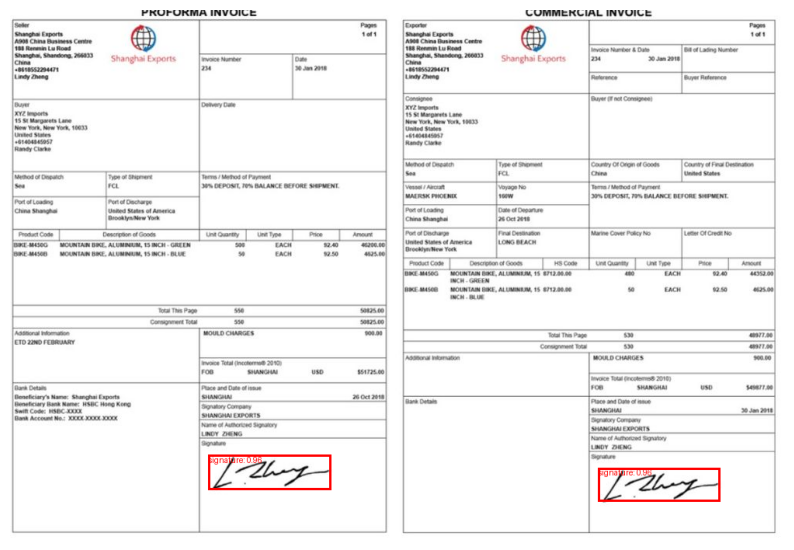

In [ ]:
import torch
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForObjectDetection
import requests
# -----------------------------
# Load model
# -----------------------------
MODEL_PATH = "/content/drive/MyDrive/final_qr_model"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(MODEL_PATH).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(MODEL_PATH)

model.eval()

# -----------------------------
# Load image
# -----------------------------
# image_path = "/content/QRcode_1.jpg"
# image = Image.open(image_path).convert("RGB")

URL = "https://quickbooks.intuit.com/learn-support/image/serverpage/image-id/62933i9581A4B2869E3208/image-size/large?v=v2&px=999"

image = Image.open(requests.get(URL, stream=True).raw).convert("RGB")


# -----------------------------
# Preprocess
# -----------------------------
inputs = processor(images=image, return_tensors="pt").to(DEVICE)

# -----------------------------
# Inference
# -----------------------------
with torch.no_grad():
    outputs = model(**inputs)

# -----------------------------
# Post-process
# -----------------------------
w, h = image.size

results = processor.post_process_object_detection(
    outputs,
    target_sizes=[(h, w)],
    threshold=0.3
)

# -----------------------------
# Draw boxes using PIL
# -----------------------------
draw = ImageDraw.Draw(image)

for score, label, box in zip(
    results[0]["scores"],
    results[0]["labels"],
    results[0]["boxes"]
):
    box = box.tolist()
    class_name = model.config.id2label[label.item()]
    score = score.item()

    # Draw rectangle
    draw.rectangle(box, outline="red", width=3)

    # Draw label
    text = f"{class_name}: {score:.2f}"
    draw.text((box[0], box[1]), text, fill="red")

# -----------------------------
# Show using matplotlib
# -----------------------------
plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.show()